# Dense RRF fusion sweeps (Recall@5000)

Two experiments, same mechanics: weighted RRF over two dense runs per query, then **mean Recall@5000** (`retrieval_eval.common.recall_at_k`).

1. **HyDE vs MedEmbed (orig query):** `bm25_new/dense` (query_hyde) + `bm25_new/dense_` — three splits (incl. Phase B).
2. **BGE-M3 vs MedEmbed (orig query):** `bgem3/dense` + `bm25_new/dense_` — two splits (3pct + 13b golden; no Phase B run under bgem3).

One figure per (experiment, split). Results include an `experiment` column.


In [7]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

_shared = base_dir / "scripts" / "public" / "shared_scripts"
if str(_shared) not in sys.path:
    sys.path.insert(0, str(_shared))

from retrieval_eval.common import recall_at_k

output_dir = base_dir / "output" / "retrieval_test" / "dense_hyde_fusion_sweep"
output_dir.mkdir(parents=True, exist_ok=True)

print("base_dir:", base_dir)
print("figures:", output_dir)

base_dir: /Users/yun/develop/BioASQ
figures: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep


In [8]:
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {_extract_pmid(d) for d in docs if _extract_pmid(d)}
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    return {
        str(qid): grp[doc_col].astype(str).tolist()
        for qid, grp in run_df.groupby(qid_col, sort=False)
    }


def _rrf_fuse_two_lists(
    docs_a: list[str],
    docs_b: list[str],
    pool_a: int,
    pool_b: int,
    k_rrf: int,
    w_a: float,
    w_b: float,
) -> list[str]:
    a_top = docs_a[:pool_a]
    b_top = docs_b[:pool_b]
    rank_a = {d: i + 1 for i, d in enumerate(a_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    union = list(dict.fromkeys(a_top + b_top))
    scored = []
    for d in union:
        s = 0.0
        ra = rank_a.get(d)
        rb = rank_b.get(d)
        if ra is not None:
            s += w_a / (k_rrf + ra)
        if rb is not None:
            s += w_b / (k_rrf + rb)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


def mean_recall_at_k_fused(
    gold: dict[str, set[str]],
    run_a: dict[str, list[str]],
    run_b: dict[str, list[str]],
    *,
    k_rrf: int,
    w_a: float,
    w_b: float,
    pool_top: int,
    k_eval: int,
) -> tuple[float, int]:
    qids = [q for q in gold if q in run_a and q in run_b and gold[q]]
    if not qids:
        return 0.0, 0
    recalls: list[float] = []
    for q in qids:
        docs_a = run_a[q]
        docs_b = run_b[q]
        pool_pa = min(pool_top, len(docs_a)) if docs_a else 0
        pool_pb = min(pool_top, len(docs_b)) if docs_b else 0
        fused = _rrf_fuse_two_lists(
            docs_a,
            docs_b,
            pool_pa,
            pool_pb,
            k_rrf=k_rrf,
            w_a=w_a,
            w_b=w_b,
        )
        fused = fused[:k_eval]
        recalls.append(recall_at_k(set(gold[q]), fused, k_eval))
    return float(np.mean(recalls)) if recalls else 0.0, len(qids)

In [9]:
RUN_POOL_TOP = 5000
K_EVAL = 5000
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]

split_labels = {
    "training14b_3pct_sample": "training14b_3pct (dev sample)",
    "13b_golden_50q_sample": "13b golden 50q",
    "BioASQ-task14bPhaseB-testset1": "14b Phase B testset1",
}

FUSION_SWEEPS: list[dict] = [
    {
        "experiment": "hyde_vs_medembed_orig",
        "plot_title": "HyDE + MedEmbed orig",
        "xlabel_weights": "(w_hyde, w_medembed_orig)",
        "datasets": [
            {
                "split": "training14b_3pct_sample",
                "tsv_a": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense"
                / "runs"
                / "dense_training14b_3pct_sample.tsv",
                "tsv_b": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense_"
                / "runs"
                / "dense_training14b_3pct_sample.tsv",
                "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
            },
            {
                "split": "13b_golden_50q_sample",
                "tsv_a": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense"
                / "runs"
                / "dense_13b_golden_50q_sample.tsv",
                "tsv_b": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense_"
                / "runs"
                / "dense_13b_golden_50q_sample.tsv",
                "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
            },
            {
                "split": "BioASQ-task14bPhaseB-testset1",
                "tsv_a": base_dir
                / "output"
                / "retrieval_test"
                / "hyde"
                / "dense"
                / "runs"
                / "dense_BioASQ-task14bPhaseB-testset1.tsv",
                "tsv_b": base_dir
                / "bioasq14_output"
                / "batch_1"
                / "dense"
                / "runs"
                / "dense_BioASQ-task14bPhaseB-testset1.tsv",
                "qrels_path": base_dir / "bioasq_data" / "14b" / "BioASQ-task14bPhaseB-testset1",
            },
        ],
    },
    {
        "experiment": "bgem3_vs_medembed_orig",
        "plot_title": "BGE-M3 + MedEmbed orig",
        "xlabel_weights": "(w_bgem3, w_medembed_orig)",
        "datasets": [
            {
                "split": "training14b_3pct_sample",
                "tsv_a": base_dir
                / "output"
                / "retrieval_test"
                / "bgem3"
                / "dense"
                / "runs"
                / "dense_training14b_3pct_sample.tsv",
                "tsv_b": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense_"
                / "runs"
                / "dense_training14b_3pct_sample.tsv",
                "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
            },
            {
                "split": "13b_golden_50q_sample",
                "tsv_a": base_dir
                / "output"
                / "retrieval_test"
                / "bgem3"
                / "dense"
                / "runs"
                / "dense_13b_golden_50q_sample.tsv",
                "tsv_b": base_dir
                / "output"
                / "retrieval_test"
                / "bm25_new"
                / "dense_"
                / "runs"
                / "dense_13b_golden_50q_sample.tsv",
                "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
            },
        ],
    },
]


In [10]:
rrf_rows: list[dict] = []

for sweep in FUSION_SWEEPS:
    exp = sweep["experiment"]
    for spec in sweep["datasets"]:
        split = spec["split"]
        p_a = spec["tsv_a"]
        p_b = spec["tsv_b"]
        p_q = spec["qrels_path"]
        for path, label in [(p_a, "A"), (p_b, "B")]:
            if not path.exists():
                raise FileNotFoundError(f"Missing run {label} ({exp}): {path}")
        if not p_q.exists():
            raise FileNotFoundError(f"Missing qrels ({exp}): {p_q}")

        gold = _load_qrels(p_q)
        run_a = _build_run_map(_load_run(p_a))
        run_b = _build_run_map(_load_run(p_b))

        for k_rrf in RRF_KS:
            for w_a, w_b in RRF_WEIGHTS:
                mean_r, n_q = mean_recall_at_k_fused(
                    gold,
                    run_a,
                    run_b,
                    k_rrf=k_rrf,
                    w_a=w_a,
                    w_b=w_b,
                    pool_top=RUN_POOL_TOP,
                    k_eval=K_EVAL,
                )
                rrf_rows.append(
                    {
                        "experiment": exp,
                        "split": split,
                        "k_rrf": k_rrf,
                        "w_a": w_a,
                        "w_b": w_b,
                        "MeanR@5000": mean_r,
                        "n_queries": n_q,
                    }
                )

rrf_results = pd.DataFrame(rrf_rows)
rrf_results["weight_label"] = rrf_results.apply(
    lambda r: f"({r['w_a']:.1f},{r['w_b']:.1f})",
    axis=1,
)
weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

csv_path = output_dir / "dense_fusion_rrf_sweep_meanr5000.csv"
rrf_results.to_csv(csv_path, index=False)
print("Saved:", csv_path)
rrf_results.head(12)


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_fusion_rrf_sweep_meanr5000.csv


,experiment,split,k_rrf,w_a,w_b,MeanR@5000,n_queries,weight_label
0,hyde_vs_medembed_orig,training14b_3pct_sample,60,1.0,0.0,0.896256,192,"(1.0,0.0)"
1,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.9,0.1,0.897306,192,"(0.9,0.1)"
2,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.8,0.2,0.897817,192,"(0.8,0.2)"
3,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.7,0.3,0.896151,192,"(0.7,0.3)"
4,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.6,0.4,0.895862,192,"(0.6,0.4)"
5,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.5,0.5,0.892106,192,"(0.5,0.5)"
6,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.4,0.6,0.885691,192,"(0.4,0.6)"
7,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.3,0.7,0.878524,192,"(0.3,0.7)"
8,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.2,0.8,0.873006,192,"(0.2,0.8)"
9,hyde_vs_medembed_orig,training14b_3pct_sample,60,0.1,0.9,0.868636,192,"(0.1,0.9)"


In [11]:
exp_meta = {s["experiment"]: s for s in FUSION_SWEEPS}

best_rows = []
for (exp, split), grp in rrf_results.groupby(["experiment", "split"], sort=False):
    idx = grp["MeanR@5000"].idxmax()
    best_rows.append(rrf_results.loc[idx])
best_df = pd.DataFrame(best_rows).reset_index(drop=True)
print("Best weight per (experiment, split) (max MeanR@5000):")
print(best_df.to_string(index=False))


Best weight per (experiment, split) (max MeanR@5000):
            experiment                         split  k_rrf  w_a  w_b  MeanR@5000  n_queries weight_label
 hyde_vs_medembed_orig       training14b_3pct_sample     60  0.8  0.2    0.897817        192    (0.8,0.2)
 hyde_vs_medembed_orig         13b_golden_50q_sample     60  0.5  0.5    0.956013         50    (0.5,0.5)
 hyde_vs_medembed_orig BioASQ-task14bPhaseB-testset1     60  0.7  0.3    0.830993         80    (0.7,0.3)
bgem3_vs_medembed_orig       training14b_3pct_sample     60  0.5  0.5    0.874904        192    (0.5,0.5)
bgem3_vs_medembed_orig         13b_golden_50q_sample     60  0.5  0.5    0.925761         50    (0.5,0.5)


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_rrf_meanr5000__hyde_vs_medembed_orig__training14b_3pct_sample.png


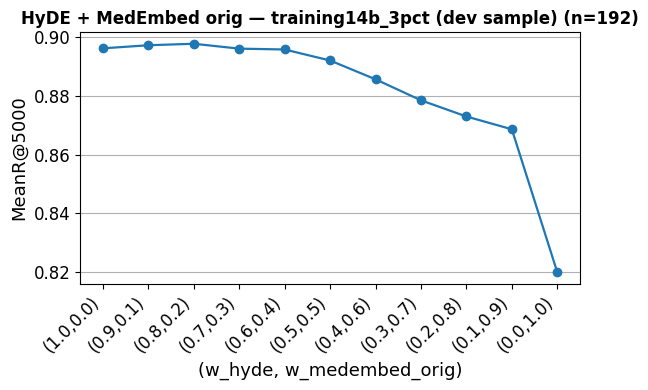

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_rrf_meanr5000__hyde_vs_medembed_orig__13b_golden_50q_sample.png


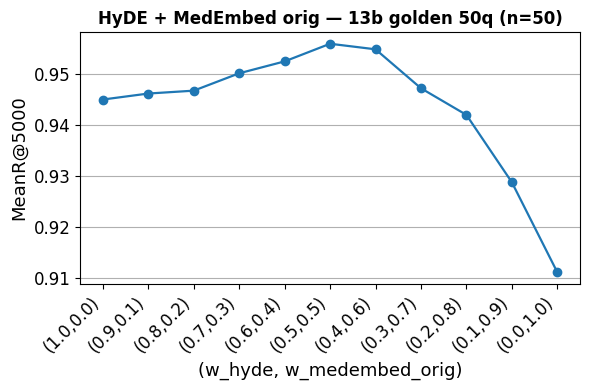

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_rrf_meanr5000__hyde_vs_medembed_orig__BioASQ-task14bPhaseB-testset1.png


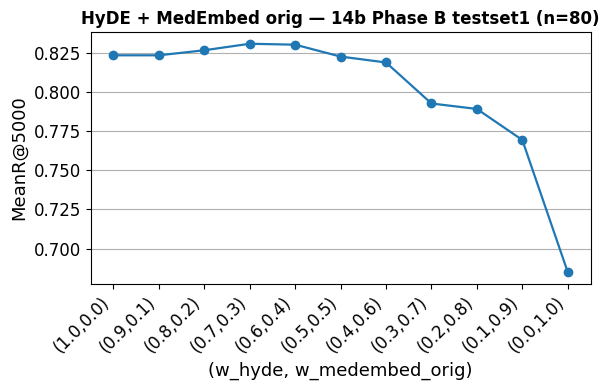

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_rrf_meanr5000__bgem3_vs_medembed_orig__training14b_3pct_sample.png


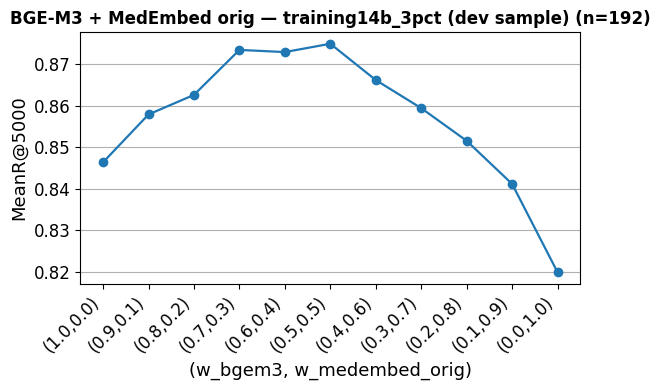

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_rrf_meanr5000__bgem3_vs_medembed_orig__13b_golden_50q_sample.png


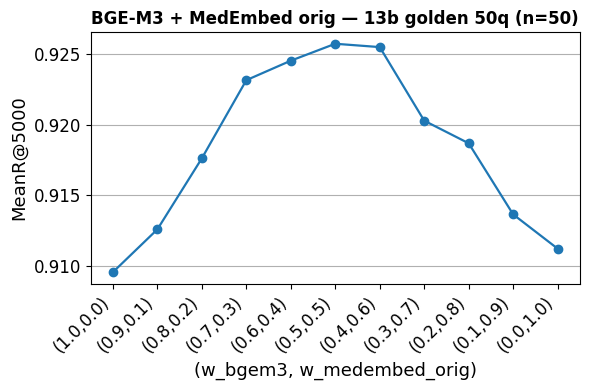

In [12]:
for (exp, split), grp in rrf_results.groupby(["experiment", "split"], sort=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    meta = exp_meta[exp]
    for k_rrf in sorted(grp["k_rrf"].unique()):
        sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
        vals = sub["MeanR@5000"].values
        ax.plot(
            range(len(weight_order)),
            vals,
            marker="o",
            linewidth=1.6,
            label=f"k_rrf={k_rrf}",
        )
    ax.set_xticks(range(len(weight_order)))
    ax.set_xticklabels(weight_order, rotation=45, ha="right")
    n_q = int(grp["n_queries"].max())
    title = split_labels.get(split, split)
    ax.set_title(
        f"{meta['plot_title']} — {title} (n={n_q})",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("MeanR@5000")
    ax.set_xlabel(meta["xlabel_weights"])
    ax.grid(True, axis="y")
    if len(RRF_KS) > 1:
        ax.legend()
    plt.tight_layout()
    safe_split = split.replace(" ", "_").replace("/", "_")
    fig_path = output_dir / f"dense_rrf_meanr5000__{exp}__{safe_split}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()


## Three-way RRF (no plot)

Fuse **BGE-M3**, **MedEmbed (orig, `dense_`)**, and **MedEmbed HyDE (`dense`)** with weights in `{1, 2}` each (8 tuples). Same `k_rrf=60` and R@5000 setup as above. Table sorted by **MeanR@5000** (all splits combined in one sort).

In [13]:
from itertools import product

THREE_WAY_K_RRF = 60
# (w_bgem3, w_medembed_orig, w_medembed_hyde) — each in {1, 2}
THREE_WAY_WEIGHTS = list(product([1.0, 2.0], [1.0, 2.0], [1.0, 2.0]))


def _rrf_fuse_three_lists(
    docs_a: list[str],
    docs_b: list[str],
    docs_c: list[str],
    pool_a: int,
    pool_b: int,
    pool_c: int,
    k_rrf: int,
    w_a: float,
    w_b: float,
    w_c: float,
) -> list[str]:
    a_top = docs_a[:pool_a]
    b_top = docs_b[:pool_b]
    c_top = docs_c[:pool_c]
    rank_a = {d: i + 1 for i, d in enumerate(a_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    rank_c = {d: i + 1 for i, d in enumerate(c_top)}
    union = list(dict.fromkeys(a_top + b_top + c_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        if (ra := rank_a.get(d)) is not None:
            s += w_a / (k_rrf + ra)
        if (rb := rank_b.get(d)) is not None:
            s += w_b / (k_rrf + rb)
        if (rc := rank_c.get(d)) is not None:
            s += w_c / (k_rrf + rc)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


def mean_recall_three_way(
    gold: dict[str, set[str]],
    run_bgem3: dict[str, list[str]],
    run_med: dict[str, list[str]],
    run_hyde: dict[str, list[str]],
    *,
    k_rrf: int,
    w_bgem3: float,
    w_med: float,
    w_hyde: float,
    pool_top: int,
    k_eval: int,
) -> tuple[float, int]:
    qids = [
        q
        for q in gold
        if q in run_bgem3 and q in run_med and q in run_hyde and gold[q]
    ]
    if not qids:
        return 0.0, 0
    recalls: list[float] = []
    for q in qids:
        d_bg = run_bgem3[q]
        d_me = run_med[q]
        d_hy = run_hyde[q]
        pa = min(pool_top, len(d_bg)) if d_bg else 0
        pb = min(pool_top, len(d_me)) if d_me else 0
        pc = min(pool_top, len(d_hy)) if d_hy else 0
        fused = _rrf_fuse_three_lists(
            d_bg,
            d_me,
            d_hy,
            pa,
            pb,
            pc,
            k_rrf,
            w_bgem3,
            w_med,
            w_hyde,
        )[:k_eval]
        recalls.append(recall_at_k(set(gold[q]), fused, k_eval))
    return float(np.mean(recalls)) if recalls else 0.0, len(qids)


THREE_WAY_DATASETS = [
    {
        "split": "training14b_3pct_sample",
        "p_bgem3": base_dir
        / "output"
        / "retrieval_test"
        / "bgem3"
        / "dense"
        / "runs"
        / "dense_training14b_3pct_sample.tsv",
        "p_medembed": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense_"
        / "runs"
        / "dense_training14b_3pct_sample.tsv",
        "p_hyde": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense"
        / "runs"
        / "dense_training14b_3pct_sample.tsv",
        "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
    },
    {
        "split": "13b_golden_50q_sample",
        "p_bgem3": base_dir
        / "output"
        / "retrieval_test"
        / "bgem3"
        / "dense"
        / "runs"
        / "dense_13b_golden_50q_sample.tsv",
        "p_medembed": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense_"
        / "runs"
        / "dense_13b_golden_50q_sample.tsv",
        "p_hyde": base_dir
        / "output"
        / "retrieval_test"
        / "bm25_new"
        / "dense"
        / "runs"
        / "dense_13b_golden_50q_sample.tsv",
        "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
    },
]

rows_three: list[dict] = []
for spec in THREE_WAY_DATASETS:
    split = spec["split"]
    paths = [
        (spec["p_bgem3"], "bgem3"),
        (spec["p_medembed"], "medembed_orig"),
        (spec["p_hyde"], "medembed_hyde"),
    ]
    for path, label in paths:
        if not path.exists():
            raise FileNotFoundError(f"Missing {label} run: {path}")
    if not spec["qrels_path"].exists():
        raise FileNotFoundError(f"Missing qrels: {spec['qrels_path']}")

    gold = _load_qrels(spec["qrels_path"])
    run_bgem3 = _build_run_map(_load_run(spec["p_bgem3"]))
    run_med = _build_run_map(_load_run(spec["p_medembed"]))
    run_hyde = _build_run_map(_load_run(spec["p_hyde"]))

    for w_bg, w_me, w_hy in THREE_WAY_WEIGHTS:
        mean_r, n_q = mean_recall_three_way(
            gold,
            run_bgem3,
            run_med,
            run_hyde,
            k_rrf=THREE_WAY_K_RRF,
            w_bgem3=w_bg,
            w_med=w_me,
            w_hyde=w_hy,
            pool_top=RUN_POOL_TOP,
            k_eval=K_EVAL,
        )
        rows_three.append(
            {
                "split": split,
                "w_bgem3": int(w_bg),
                "w_medembed": int(w_me),
                "w_medembed_hyde": int(w_hy),
                "weight_tuple": f"({int(w_bg)},{int(w_me)},{int(w_hy)})",
                "MeanR@5000": mean_r,
                "n_queries": n_q,
            }
        )

three_way_df = pd.DataFrame(rows_three).sort_values(
    "MeanR@5000", ascending=False, ignore_index=True
)
three_way_df.to_csv(output_dir / "dense_three_way_rrf_meanr5000_weights123.csv", index=False)
print("Saved:", output_dir / "dense_three_way_rrf_meanr5000_weights123.csv")
three_way_df


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_three_way_rrf_meanr5000_weights123.csv


,split,w_bgem3,w_medembed,w_medembed_hyde,weight_tuple,MeanR@5000,n_queries
0,13b_golden_50q_sample,2,1,2,"(2,1,2)",0.962533,50
1,13b_golden_50q_sample,1,1,2,"(1,1,2)",0.961689,50
2,13b_golden_50q_sample,1,2,2,"(1,2,2)",0.961672,50
3,13b_golden_50q_sample,1,1,1,"(1,1,1)",0.958090,50
4,13b_golden_50q_sample,2,2,2,"(2,2,2)",0.958090,50
5,13b_golden_50q_sample,1,2,1,"(1,2,1)",0.956811,50
6,13b_golden_50q_sample,2,1,1,"(2,1,1)",0.955884,50
7,13b_golden_50q_sample,2,2,1,"(2,2,1)",0.955819,50
8,training14b_3pct_sample,1,1,2,"(1,1,2)",0.921799,192
9,training14b_3pct_sample,2,1,2,"(2,1,2)",0.919354,192


## Fixed-weight hybrid fusion (BM25 + dense runs)

Single **MeanR@5000** per row for three hand-picked RRF recipes (`k_rrf=60`), on the two 3pc splits (same corpus as `bm25_new` / `bgem3`).

- **MedEmbed** = `bm25_new/dense_` (original query). **HyDE** = `bm25_new/dense`. **BGE-M3** = `bgem3/dense`. **BM25** = `bm25_new/bm25` (RM3).

In [14]:
FIXED_HYBRID_K_RRF = 60

FIXED_HYBRID_CASES: list[dict] = [
    {
        "label": "BM25 + MedEmbed + HyDE",
        "components": ("bm25", "medembed_orig", "hyde"),
        "weights": (0.4, 0.2, 0.4),
    },
    {
        "label": "BM25 + MedEmbed + BGE-M3",
        "components": ("bm25", "medembed_orig", "bgem3"),
        "weights": (0.4, 0.3, 0.3),
    },
    {
        "label": "BM25 + MedEmbed + HyDE + BGE-M3",
        "components": ("bm25", "medembed_orig", "hyde", "bgem3"),
        "weights": (0.4, 0.1, 0.2, 0.3),
    },
]


def _stem_and_bm25_name(split: str) -> tuple[str, str]:
    if split == "training14b_3pct_sample":
        return (
            "dense_training14b_3pct_sample.tsv",
            "BM25_RM3__training14b_3pct_sample__top5000.tsv",
        )
    if split == "13b_golden_50q_sample":
        return (
            "dense_13b_golden_50q_sample.tsv",
            "BM25_RM3__13b_golden_50q_sample__top5000.tsv",
        )
    raise ValueError(f"Unsupported split for fixed hybrid: {split}")


def _path_fixed_hybrid(split: str, component: str) -> Path:
    rt = base_dir / "output" / "retrieval_test"
    dense_stem, bm25_name = _stem_and_bm25_name(split)
    if component == "bm25":
        return rt / "bm25_new" / "bm25" / "runs" / bm25_name
    if component == "medembed_orig":
        return rt / "bm25_new" / "dense_" / "runs" / dense_stem
    if component == "hyde":
        return rt / "bm25_new" / "dense" / "runs" / dense_stem
    if component == "bgem3":
        return rt / "bgem3" / "dense" / "runs" / dense_stem
    raise ValueError(component)


def _rrf_fuse_many(
    doc_lists: list[list[str]],
    pools: list[int],
    k_rrf: int,
    weights: list[float],
) -> list[str]:
    if len(doc_lists) != len(pools) or len(weights) != len(doc_lists):
        raise ValueError("doc_lists, pools, weights must match length")
    truncated = [lst[:p] for lst, p in zip(doc_lists, pools)]
    rank_maps = [{d: i + 1 for i, d in enumerate(lst)} for lst in truncated]
    union: list[str] = []
    seen: set[str] = set()
    for lst in truncated:
        for d in lst:
            if d not in seen:
                seen.add(d)
                union.append(d)
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        for w, rmap in zip(weights, rank_maps):
            rnk = rmap.get(d)
            if rnk is not None:
                s += w / (k_rrf + rnk)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


def mean_recall_many_fused(
    gold: dict[str, set[str]],
    run_maps: list[dict[str, list[str]]],
    weights: tuple[float, ...],
    *,
    k_rrf: int,
    pool_top: int,
    k_eval: int,
) -> tuple[float, int]:
    if len(run_maps) != len(weights):
        raise ValueError("run_maps and weights length mismatch")
    qids = [
        q
        for q in gold
        if all(q in rm for rm in run_maps) and gold[q]
    ]
    if not qids:
        return 0.0, 0
    recalls: list[float] = []
    w_list = list(weights)
    for q in qids:
        doc_lists = [rm[q] for rm in run_maps]
        pools = [min(pool_top, len(d)) if d else 0 for d in doc_lists]
        fused = _rrf_fuse_many(doc_lists, pools, k_rrf, w_list)[:k_eval]
        recalls.append(recall_at_k(set(gold[q]), fused, k_eval))
    return float(np.mean(recalls)) if recalls else 0.0, len(qids)


FIXED_HYBRID_SPLITS = [
    {
        "split": "training14b_3pct_sample",
        "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
    },
    {
        "split": "13b_golden_50q_sample",
        "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
    },
]

rows_fixed: list[dict] = []
for split_spec in FIXED_HYBRID_SPLITS:
    split = split_spec["split"]
    p_q = split_spec["qrels_path"]
    if not p_q.exists():
        raise FileNotFoundError(f"Missing qrels: {p_q}")
    gold = _load_qrels(p_q)

    for case in FIXED_HYBRID_CASES:
        comps = case["components"]
        wts = case["weights"]
        paths = [_path_fixed_hybrid(split, c) for c in comps]
        for path, c in zip(paths, comps):
            if not path.exists():
                raise FileNotFoundError(f"Missing {c} run: {path}")
        run_maps = [_build_run_map(_load_run(path)) for path in paths]
        mean_r, n_q = mean_recall_many_fused(
            gold,
            run_maps,
            wts,
            k_rrf=FIXED_HYBRID_K_RRF,
            pool_top=RUN_POOL_TOP,
            k_eval=K_EVAL,
        )
        rows_fixed.append(
            {
                "split": split,
                "recipe": case["label"],
                "weights": str(tuple(wts)),
                "components": ",".join(comps),
                "MeanR@5000": mean_r,
                "n_queries": n_q,
            }
        )

fixed_hybrid_df = pd.DataFrame(rows_fixed).sort_values(
    ["split", "MeanR@5000"], ascending=[True, False], ignore_index=True
)
out_csv = output_dir / "dense_fixed_hybrid_rrf_meanr5000.csv"
fixed_hybrid_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
fixed_hybrid_df


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_fixed_hybrid_rrf_meanr5000.csv


,split,recipe,weights,components,MeanR@5000,n_queries
0,13b_golden_50q_sample,BM25 + MedEmbed + HyDE + BGE-M3,"(0.4, 0.1, 0.2, 0.3)","bm25,medembed_orig,hyde,bgem3",0.975219,50
1,13b_golden_50q_sample,BM25 + MedEmbed + HyDE,"(0.4, 0.2, 0.4)","bm25,medembed_orig,hyde",0.970463,50
2,13b_golden_50q_sample,BM25 + MedEmbed + BGE-M3,"(0.4, 0.3, 0.3)","bm25,medembed_orig,bgem3",0.970353,50
3,training14b_3pct_sample,BM25 + MedEmbed + HyDE + BGE-M3,"(0.4, 0.1, 0.2, 0.3)","bm25,medembed_orig,hyde,bgem3",0.964690,191
4,training14b_3pct_sample,BM25 + MedEmbed + HyDE,"(0.4, 0.2, 0.4)","bm25,medembed_orig,hyde",0.957058,191
5,training14b_3pct_sample,BM25 + MedEmbed + BGE-M3,"(0.4, 0.3, 0.3)","bm25,medembed_orig,bgem3",0.956343,191


## Final summary: MeanR@5000 per recipe (two tables)

Single systems, two two-way RRF mixes `(0.5, 0.5)`, and the three fixed multi-way recipes. One **CSV per split** under `output_dir`.

In [15]:
SUMMARY_K_RRF = 60

SUMMARY_CONFIGS: list[dict] = [
    {"recipe": "BM25", "kind": "single", "components": ("bm25",), "weights": None},
    {"recipe": "MedEmbed", "kind": "single", "components": ("medembed_orig",), "weights": None},
    {"recipe": "HyDE", "kind": "single", "components": ("hyde",), "weights": None},
    {"recipe": "BGE-M3", "kind": "single", "components": ("bgem3",), "weights": None},
    {
        "recipe": "BM25 + MedEmbed",
        "kind": "pair",
        "components": ("bm25", "medembed_orig"),
        "weights": (0.5, 0.5),
    },
    {
        "recipe": "BM25 + BGE-M3",
        "kind": "pair",
        "components": ("bm25", "bgem3"),
        "weights": (0.5, 0.5),
    },
    {
        "recipe": "BM25 + MedEmbed + HyDE",
        "kind": "many",
        "components": ("bm25", "medembed_orig", "hyde"),
        "weights": (0.4, 0.2, 0.4),
    },
    {
        "recipe": "BM25 + MedEmbed + BGE-M3",
        "kind": "many",
        "components": ("bm25", "medembed_orig", "bgem3"),
        "weights": (0.4, 0.3, 0.3),
    },
    {
        "recipe": "BM25 + MedEmbed + HyDE + BGE-M3",
        "kind": "many",
        "components": ("bm25", "medembed_orig", "hyde", "bgem3"),
        "weights": (0.4, 0.1, 0.2, 0.3),
    },
]


def mean_recall_single_run(
    gold: dict[str, set[str]],
    run_map: dict[str, list[str]],
    *,
    pool_top: int,
    k_eval: int,
) -> tuple[float, int]:
    qids = [q for q in gold if q in run_map and gold[q]]
    if not qids:
        return 0.0, 0
    recalls: list[float] = []
    for q in qids:
        docs = run_map[q]
        take = min(pool_top, len(docs)) if docs else 0
        ranked = docs[:take][:k_eval]
        recalls.append(recall_at_k(set(gold[q]), ranked, k_eval))
    return float(np.mean(recalls)) if recalls else 0.0, len(qids)


def _eval_summary_config(
    gold: dict[str, set[str]],
    split: str,
    cfg: dict,
) -> tuple[float, int]:
    kind = cfg["kind"]
    comps = cfg["components"]
    paths = [_path_fixed_hybrid(split, c) for c in comps]
    for path, c in zip(paths, comps):
        if not path.exists():
            raise FileNotFoundError(f"Missing {c} run: {path}")

    if kind == "single":
        rm = _build_run_map(_load_run(paths[0]))
        return mean_recall_single_run(
            gold, rm, pool_top=RUN_POOL_TOP, k_eval=K_EVAL
        )

    run_maps = [_build_run_map(_load_run(p)) for p in paths]

    if kind == "pair":
        w0, w1 = cfg["weights"]
        return mean_recall_at_k_fused(
            gold,
            run_maps[0],
            run_maps[1],
            k_rrf=SUMMARY_K_RRF,
            w_a=w0,
            w_b=w1,
            pool_top=RUN_POOL_TOP,
            k_eval=K_EVAL,
        )

    if kind == "many":
        return mean_recall_many_fused(
            gold,
            run_maps,
            cfg["weights"],
            k_rrf=SUMMARY_K_RRF,
            pool_top=RUN_POOL_TOP,
            k_eval=K_EVAL,
        )

    raise ValueError(kind)


summary_tables: dict[str, pd.DataFrame] = {}
for split_spec in FIXED_HYBRID_SPLITS:
    split = split_spec["split"]
    p_q = split_spec["qrels_path"]
    if not p_q.exists():
        raise FileNotFoundError(f"Missing qrels: {p_q}")
    gold = _load_qrels(p_q)
    rows_s: list[dict] = []
    for cfg in SUMMARY_CONFIGS:
        mean_r, n_q = _eval_summary_config(gold, split, cfg)
        w = cfg["weights"]
        rows_s.append(
            {
                "recipe": cfg["recipe"],
                "kind": cfg["kind"],
                "weights": None if w is None else str(tuple(w)),
                "MeanR@5000": mean_r,
                "n_queries": n_q,
            }
        )
    summary_tables[split] = pd.DataFrame(rows_s)

for split, df_s in summary_tables.items():
    safe = split.replace("/", "_")
    out_p = output_dir / f"dense_summary_meanr5000__{safe}.csv"
    df_s.to_csv(out_p, index=False)
    print("Saved:", out_p)

summary_tables["training14b_3pct_sample"]


Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_summary_meanr5000__training14b_3pct_sample.csv
Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_summary_meanr5000__13b_golden_50q_sample.csv


,recipe,kind,weights,MeanR@5000,n_queries
0,BM25,single,NaN,0.931221,191
1,MedEmbed,single,NaN,0.819882,192
2,HyDE,single,NaN,0.896256,192
3,BGE-M3,single,NaN,0.846369,192
4,BM25 + MedEmbed,pair,"(0.5, 0.5)",0.946949,191
5,BM25 + BGE-M3,pair,"(0.5, 0.5)",0.951214,191
6,BM25 + MedEmbed + HyDE,many,"(0.4, 0.2, 0.4)",0.957058,191
7,BM25 + MedEmbed + BGE-M3,many,"(0.4, 0.3, 0.3)",0.956343,191
8,BM25 + MedEmbed + HyDE + BGE-M3,many,"(0.4, 0.1, 0.2, 0.3)",0.964690,191


In [16]:
summary_tables["13b_golden_50q_sample"]

,recipe,kind,weights,MeanR@5000,n_queries
0,BM25,single,NaN,0.946742,50
1,MedEmbed,single,NaN,0.911212,50
2,HyDE,single,NaN,0.945074,50
3,BGE-M3,single,NaN,0.909540,50
4,BM25 + MedEmbed,pair,"(0.5, 0.5)",0.967743,50
5,BM25 + BGE-M3,pair,"(0.5, 0.5)",0.965401,50
6,BM25 + MedEmbed + HyDE,many,"(0.4, 0.2, 0.4)",0.970463,50
7,BM25 + MedEmbed + BGE-M3,many,"(0.4, 0.3, 0.3)",0.970353,50
8,BM25 + MedEmbed + HyDE + BGE-M3,many,"(0.4, 0.1, 0.2, 0.3)",0.975219,50


## Recall curves: HyDE vs original (one figure, 3 panels)

Plots **mean Recall@K** for HyDE vs original query dense runs across K in `[50..5000]`, one panel per dataset.

Saved: /Users/yun/develop/BioASQ/output/retrieval_test/dense_hyde_fusion_sweep/dense_hyde_vs_orig_recall_curves.png


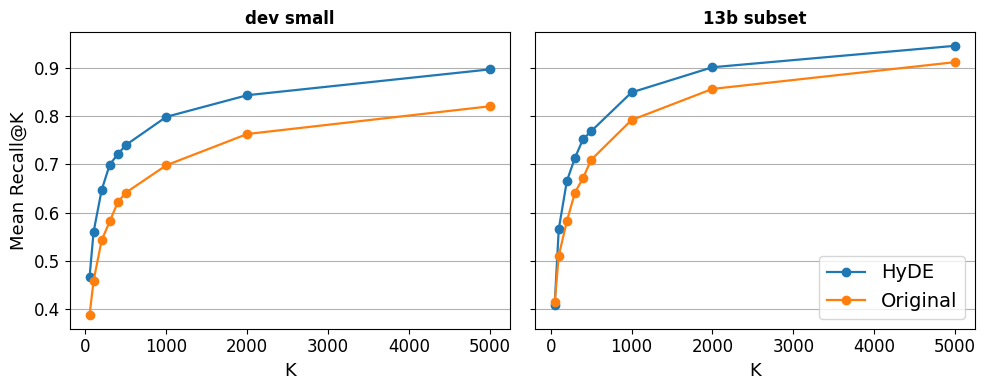

In [23]:
RECALL_CURVE_KS = [50, 100, 200, 300, 400, 500, 1000, 2000, 5000]


def mean_recall_curve(
    gold: dict[str, set[str]],
    run_map: dict[str, list[str]],
    ks: list[int],
) -> dict[int, float]:
    qids = [q for q in gold if q in run_map and gold[q]]
    out: dict[int, float] = {k: 0.0 for k in ks}
    if not qids:
        return out
    per_k = {k: [] for k in ks}
    for q in qids:
        rels = set(gold[q])
        ranked = run_map[q]
        for k in ks:
            per_k[k].append(recall_at_k(rels, ranked, k))
    for k in ks:
        out[k] = float(np.mean(per_k[k])) if per_k[k] else 0.0
    return out


HYDE_ORIG_RECALL_SPECS = [
    {
        "split": "dev small",
        "hyde_tsv": base_dir / "output" / "retrieval_test" / "bm25_new" / "dense" / "runs" / "dense_training14b_3pct_sample.tsv",
        "orig_tsv": base_dir / "output" / "retrieval_test" / "bm25_new" / "dense_" / "runs" / "dense_training14b_3pct_sample.tsv",
        "qrels_path": base_dir / "example" / "training14b_3pct_sample.json",
    },
    {
        "split": "13b subset",
        "hyde_tsv": base_dir / "output" / "retrieval_test" / "bm25_new" / "dense" / "runs" / "dense_13b_golden_50q_sample.tsv",
        "orig_tsv": base_dir / "output" / "retrieval_test" / "bm25_new" / "dense_" / "runs" / "dense_13b_golden_50q_sample.tsv",
        "qrels_path": base_dir / "example" / "13b_golden_50q_sample.json",
    },
    # {
    #     "split": "BioASQ-task14bPhaseB-testset1",
    #     "hyde_tsv": base_dir / "output" / "retrieval_test" / "hyde" / "dense" / "runs" / "dense_BioASQ-task14bPhaseB-testset1.tsv",
    #     "orig_tsv": base_dir / "bioasq14_output" / "batch_1" / "dense" / "runs" / "dense_BioASQ-task14bPhaseB-testset1.tsv",
    #     "qrels_path": base_dir / "bioasq_data" / "14b" / "BioASQ-task14bPhaseB-testset1",
    # },
]

n = len(HYDE_ORIG_RECALL_SPECS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, spec in zip(axes, HYDE_ORIG_RECALL_SPECS):
    split = spec["split"]
    for path, label in [(spec["hyde_tsv"], "hyde"), (spec["orig_tsv"], "orig")]:
        if not path.exists():
            raise FileNotFoundError(f"Missing {label} run: {path}")
    if not spec["qrels_path"].exists():
        raise FileNotFoundError(f"Missing qrels: {spec['qrels_path']}")

    gold = _load_qrels(spec["qrels_path"])
    run_h = _build_run_map(_load_run(spec["hyde_tsv"]))
    run_o = _build_run_map(_load_run(spec["orig_tsv"]))

    # RRF fusion line (w_hyde=0.6, w_orig=0.4)
    fused_map: dict[str, list[str]] = {}
    qids = sorted(set(run_h.keys()) | set(run_o.keys()), key=str)
    for qid in qids:
        docs_h = run_h.get(qid, [])
        docs_o = run_o.get(qid, [])
        pool_h = min(RUN_POOL_TOP, len(docs_h)) if docs_h else 0
        pool_o = min(RUN_POOL_TOP, len(docs_o)) if docs_o else 0
        fused_map[qid] = _rrf_fuse_two_lists(
            docs_h,
            docs_o,
            pool_h,
            pool_o,
            k_rrf=60,
            w_a=0.6,
            w_b=0.4,
        )[:RUN_POOL_TOP]

    c_h = mean_recall_curve(gold, run_h, RECALL_CURVE_KS)
    c_o = mean_recall_curve(gold, run_o, RECALL_CURVE_KS)
    c_f = mean_recall_curve(gold, fused_map, RECALL_CURVE_KS)

    xs = RECALL_CURVE_KS
    ax.plot(xs, [c_h[k] for k in xs], marker='o', linewidth=1.6, label='HyDE')
    ax.plot(xs, [c_o[k] for k in xs], marker='o', linewidth=1.6, label='Original')
    # ax.plot(xs, [c_f[k] for k in xs], marker='o', linewidth=1.6, label='RRF w=(0.6,0.4)')

    title = split_labels.get(split, split)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('K')
    ax.grid(True, axis='y')

axes[0].set_ylabel('Mean Recall@K')
axes[-1].legend(loc='lower right', fontsize=14)
plt.tight_layout()
fig_path = output_dir / 'dense_hyde_vs_orig_recall_curves.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()
